<a href="https://colab.research.google.com/github/mananmalvi/ML--The-Art/blob/main/DAY_5_Decision_Tree_V_S_Random_Forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

🌳 DECISION TREE (The Lone Tree) vs. 🌲🌲🌲 RANDOM FOREST (The Entire Jungle)

FOR CLASSIFICATION PROBLEM 🚀

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split

In [2]:
np.random.seed(42)
X,y=make_circles(n_samples=500, factor=0.1, noise=0.35, random_state=42)
x_train, x_test, y_train, y_test=train_test_split(X,y , test_size=0.2, random_state=42)

In [3]:
X.shape

(500, 2)

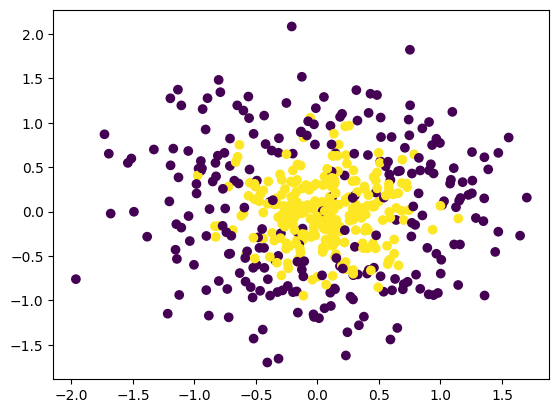

In [4]:
plt.scatter(X[:,0],X[:,1],c=y)

In [8]:
from sklearn.tree import DecisionTreeClassifier
dtree=DecisionTreeClassifier(random_state=42)
dtree.fit(x_train, y_train)

DecisionTreeClassifier(random_state=42)

DECISION TREE PLOTTTING

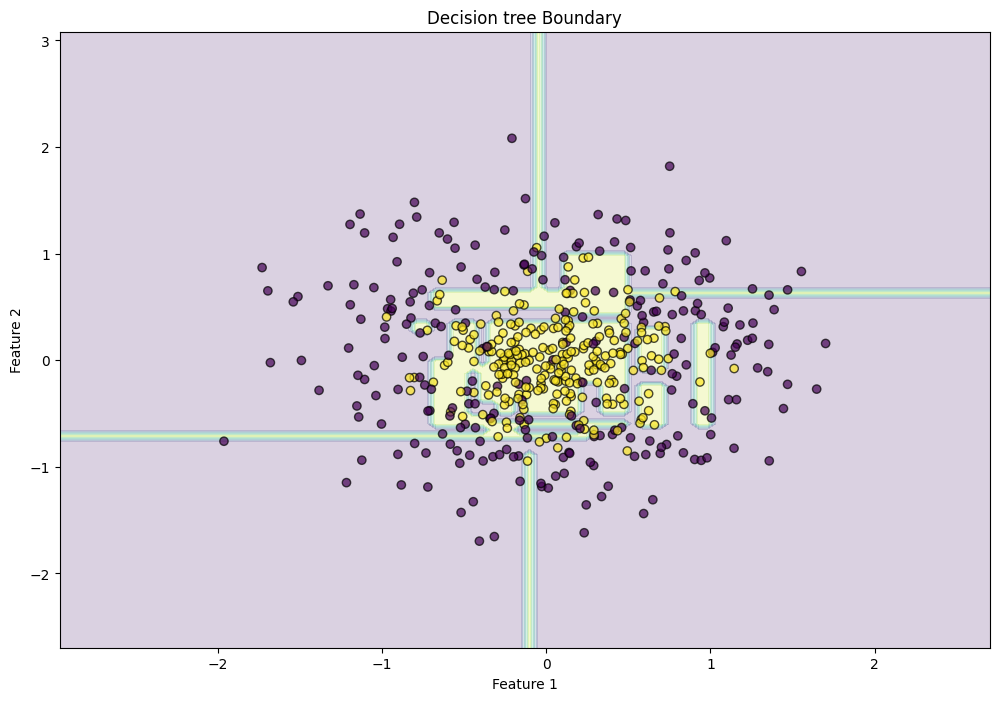

In [9]:
# Plotting the train model of decision tree over the data
plt.figure(figsize=(12, 8))

# 1. Calculate min and max for each feature (column) independently
# Adding a small buffer (e.g., +/- 1) so the data points aren't cut off at the edges
x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1

# 2. Create the meshgrid using the independent ranges
xx1, xx2 = np.meshgrid(np.linspace(x1_min, x1_max, 100),
                       np.linspace(x2_min, x2_max, 100))

# 3. Predict across the grid
y_hat = dtree.predict(np.c_[xx1.ravel(), xx2.ravel()])
y_hat = y_hat.reshape(xx1.shape)

# 4. Plot the decision boundary and the data points
# (Added the same colormap to contourf to match the scatter plot for better visuals)
plt.contourf(xx1, xx2, y_hat, alpha=0.2, cmap='viridis')
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', alpha=0.7, edgecolors='k')

plt.title("Decision tree Boundary")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

RANDOM FOREST CLASSIFIER PLOTTING

In [15]:
from sklearn.ensemble import RandomForestClassifier
rfc=RandomForestClassifier(n_estimators=500, random_state=42)
rfc.fit(x_train, y_train)

RandomForestClassifier(n_estimators=500, random_state=42)

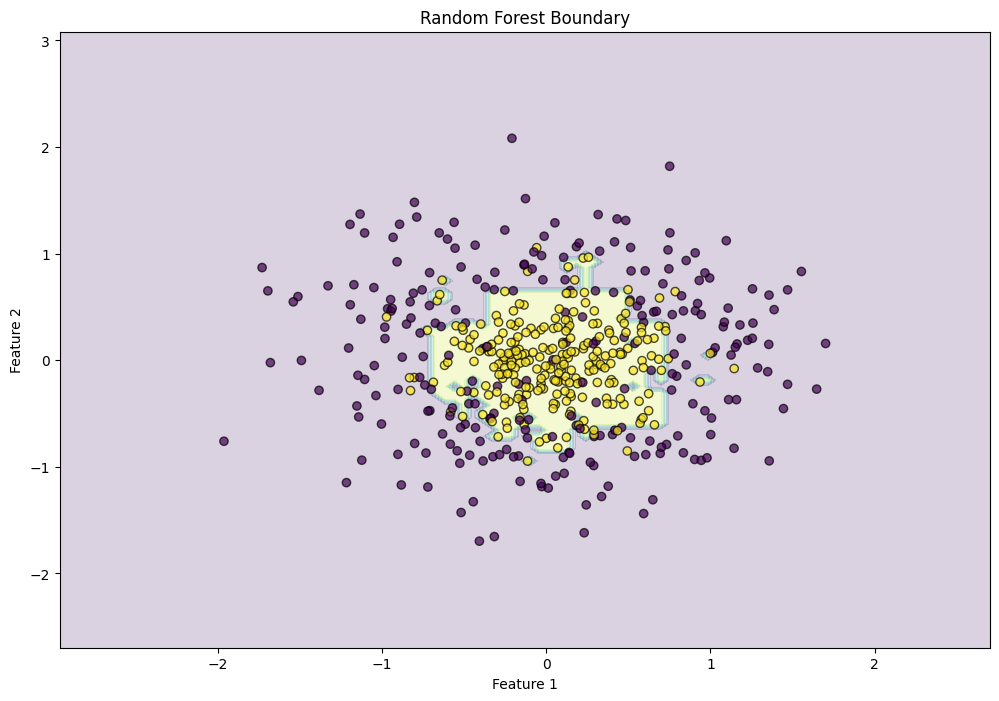

In [16]:
plt.figure(figsize=(12, 8))

# 1. Calculate min and max for each feature (column) independently
# Added a small buffer (+/- 1) so data points don't stick to the plot's edges
x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1

# 2. Create the meshgrid using the independent feature ranges
xx1, xx2 = np.meshgrid(np.linspace(x1_min, x1_max, 100),
                       np.linspace(x2_min, x2_max, 100))

# 3. Predict across the grid
y_hat = rfc.predict(np.c_[xx1.ravel(), xx2.ravel()])
y_hat = y_hat.reshape(xx1.shape)

# 4. Plot the decision boundary and the data points
# Added cmap='viridis' to contourf to match the scatter plot
plt.contourf(xx1, xx2, y_hat, alpha=0.2, cmap='viridis')

# Added edgecolors='k' for better point visibility against the background
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', alpha=0.7, edgecolors='k')

plt.title("Random Forest Boundary")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

In [ ]:
'''
-> Decision Tree (Overfitting): The decision boundary looks highly jagged, sharp, and blocky.
 It tries to perfectly capture every outlier and piece of noise,
 which means it memorizes the training data but will struggle with new data.


Random Forest (Generalizing): The decision boundary appears much smoother and more natural.
 It ignores extreme outliers and focuses on the true underlying pattern,
 using the "wisdom of the crowd" to prevent overfitting and remain highly stable.'''

FOR REGRESSION PROBLEM 🚀

In [ ]:
'''
1. The Setup: A Smooth Curve Hidden in Noise 🕵️‍♂️
y = e^{-x^2} + 1.5e^{-(x-2)^2} + epsilon
We deliberately generate "messy," non-linear data to test if the models
can find the true hidden curve or if they get distracted by the injected random noise.
It is the perfect visual test for Overfitting vs. Generalization.

2. Testing the Decision Tree: The Trap of Memorization 🪤
Due to its high variance, the Decision Tree perfectly memorizes the training data.
Instead of learning the smooth curve, it connects every single noisy dot,
resulting in a jagged, overfitted line that fails to generalize.

3. Testing the Random Forest: The Wisdom of the Crowd 🧠👥
By calculating the average of all its individual trees, the random errors cancel each other out.
It completely ignores the noise and successfully traces the smooth,
 underlying pattern, making it highly stable.'''

In [22]:
n_train = 150
n_test = 1000
noise = 0.1

# Generate data
def f(x):
    x = x.ravel()
    return np.exp(-x ** 2) + 1.5 * np.exp(-(x - 2) ** 2)

def generate(n_samples, noise):
    X = np.random.rand(n_samples) * 10 - 5
    X = np.sort(X).ravel()
    y = np.exp(-X ** 2) + 1.5 * np.exp(-(X - 2) ** 2)\
        + np.random.normal(0.0, noise, n_samples)
    X = X.reshape((n_samples, 1))

    return X, y

x_train, y_train = generate(n_samples=n_train, noise=noise)
x_test, y_test = generate(n_samples=n_test, noise=noise)

(-5.0, 5.0)

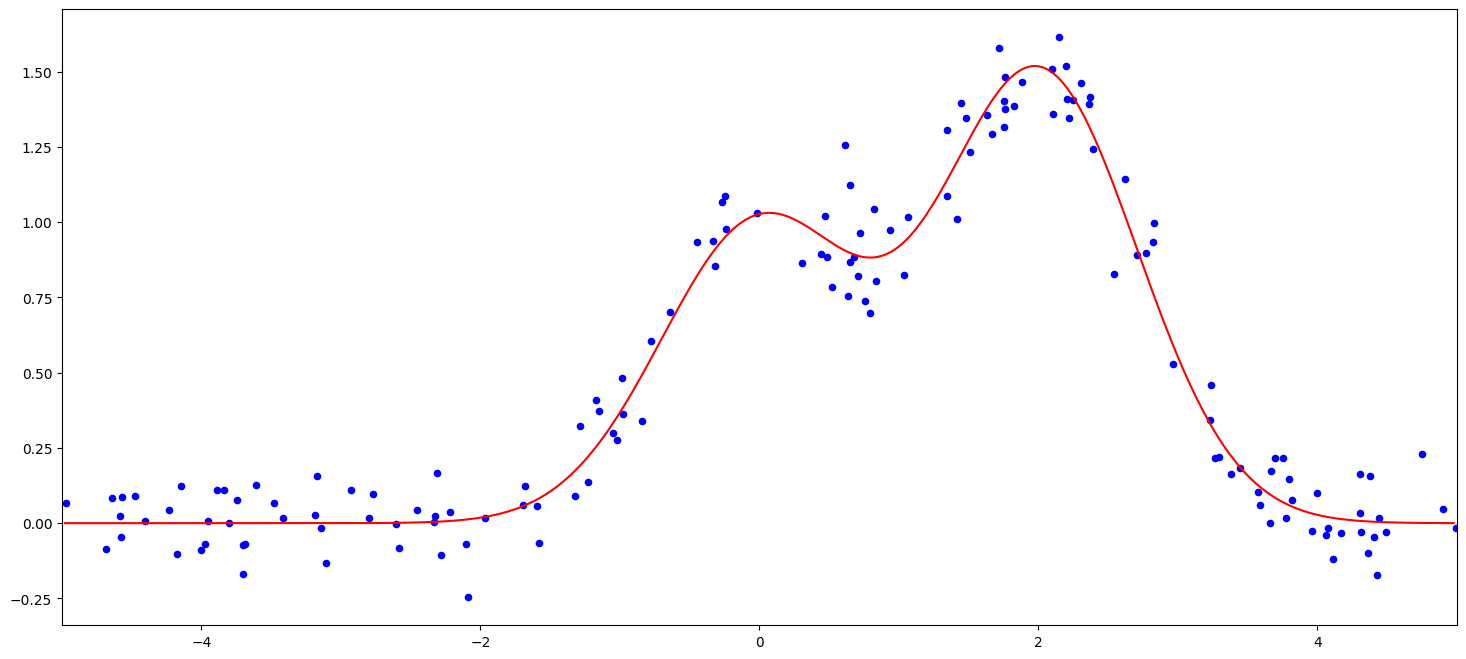

In [24]:
plt.figure(figsize=(18, 8))
plt.plot(x_test, f(x_test), "r")
plt.scatter(x_train, y_train, c="b", s=20)
plt.xlim([-5, 5])

PLOTTING DECISION TREEE REGRESSOR 🌲📈

In [27]:
# training decision tree

from sklearn.tree import DecisionTreeRegressor
dt = DecisionTreeRegressor()
dt.fit(x_train, y_train)
dt_predict= dt.predict(x_test)

Text(0.5, 1.0, 'Decision tree, MSE = 23.04')

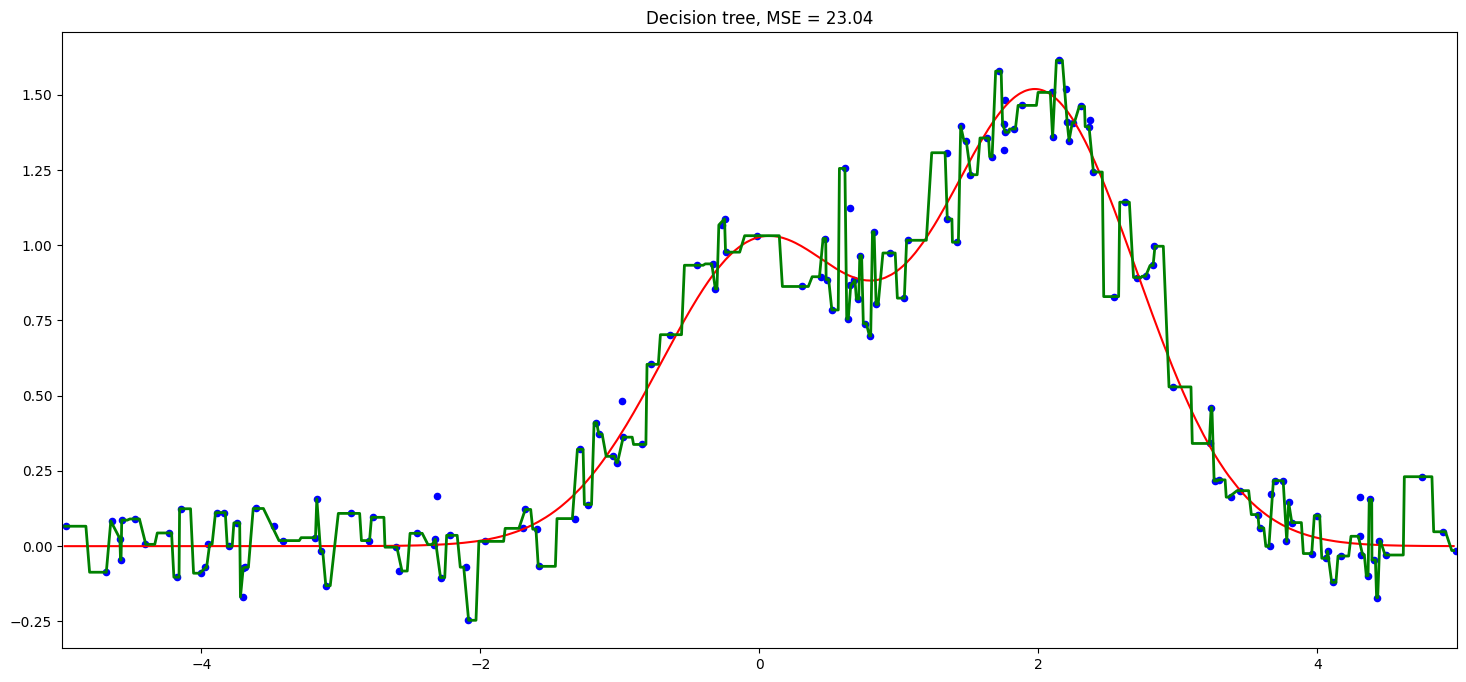

In [29]:
plt.figure(figsize=(18, 8))
plt.plot(x_test, f(x_test), "r")
plt.scatter(x_train, y_train, c="b", s=20)
plt.plot(x_test, dt_predict, "g", lw=2)
plt.xlim([-5, 5])
plt.title("Decision tree, MSE = %.2f"
          % np.sum((y_test - dt_predict) ** 2))

PLOTTING RANDOM FOREST REGRESSOR 🌲🌲🌲 📈

In [33]:
from sklearn.ensemble import RandomForestRegressor
rfr=RandomForestRegressor(n_estimators=500, random_state=42)
rfr.fit(x_train, y_train)
rfr_predict=rfr.predict(x_test)

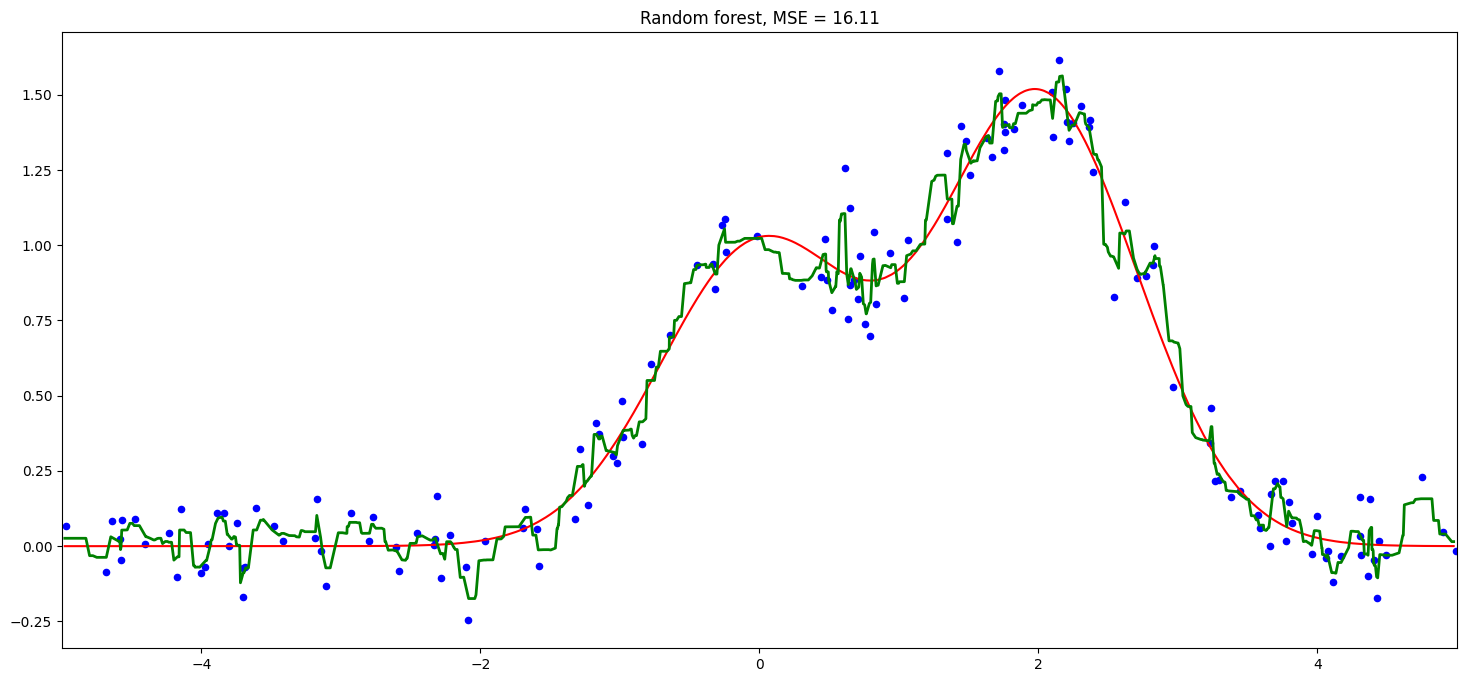

In [35]:
plt.figure(figsize=(18, 8))
plt.plot(x_test, f(x_test), "r")
plt.scatter(x_train, y_train, c="b", s=20)
plt.plot(x_test, rfr_predict, "g", lw=2)
plt.xlim([-5, 5])
plt.title("Random forest, MSE = %.2f" % np.sum((y_test - rfr_predict) ** 2));

1. The Visual Difference (What you see in the plots) 📉
Decision Tree Plot (The Overfitter) 🪤: The prediction line is highly jagged and chaotic. It tries to connect every noisy data point, completely missing the true underlying curve (resulting in a High MSE).

Random Forest Plot (The Generalizer) 🧠: The prediction line is smooth. It ignores the random noisy outliers and perfectly traces the real pattern (resulting in a Low MSE).



2. WHY does Random Forest perform better without overfitting? 🛠️
Step 1: Random Subsets (Bootstrapping) 🎲: Each of the 1000 trees is trained on a different, random subset of the data. As a result, every tree learns a different part of the random noise.

Step 2: The Averaging Effect (Aggregating) ➗: For the final prediction, the Random Forest calculates the average of all 1000 trees.

The Result (Noise Cancellation) 🎧: Because the random errors go in all different directions, averaging them cancels the noise out. The model keeps the true signal that all trees agree on, dropping variance and preventing overfitting entirely.